In [10]:
import pandas as pd
import numpy as np
import random
import os
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [11]:
BASE_DIR = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."

In [12]:
def gerar_dataset_vendas(n_registros=150, seed=42):
    """Gera um dataset de vendas com sujeira """
    random.seed(seed)            # fixa a aleatoriedade -> resultado reprodutível
    np.random.seed(seed)

    produtos = ["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado", "Mouse"]
    precos = {"Notebook": 3500, "Smartphone": 2200, "Tablet": 1800,
              "Monitor": 1200, "Teclado": 250, "Mouse": 120}
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares",
                  "Tablet": "Celulares", "Monitor": "Computadores",
                  "Teclado": "Periféricos", "Mouse": "Periféricos"}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]
    data_inicio = datetime(2024, 1, 1)

    dados = []
    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]
        data = data_inicio + timedelta(days=random.randint(0, 364))

        # Injeta defeitos em uma fração das linhas
        if random.random() < 0.05:
            quantidade = None                
        if random.random() < 0.04:
            preco = None                      
        if random.random() < 0.03:
            produto = "  " + produto          
        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"), 
            "regiao": random.choice(regioes),
            "quantidade": quantidade,
            "preco_unitario": preco,
        })
    return pd.DataFrame(dados)

df_bruto = gerar_dataset_vendas()
os.makedirs(os.path.join(BASE_DIR, "data", "raw"), exist_ok=True)
df_bruto.to_csv(os.path.join(BASE_DIR, "data", "raw", "vendas.csv"), index=False)
print(f"Dataset gerado com {len(df_bruto)} registros.")
df_bruto.head()

Dataset gerado com 150 registros.


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2.0,120.0
1,2,2024-08-04,Cliente_018,Notebook,Computadores,Sul,NaN,3500.0
2,3,DATA INVALIDA,Cliente_026,Mouse,Periféricos,Sul,9.0,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7.0,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6.0,1800.0


In [13]:
def inspecionar_dados(df):
    """Imprime um panorama do DataFrame com dimensões, colunas,
    tipos, contagem de nulos e primeiras linhas."""
    print("=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    return df.describe(include="all")


inspecionar_dados(df_bruto)

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (150, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        5
preco_unitario    2
dtype: int64

Primeiros registros:
   id_venda     data_venda      cliente   produto     categoria        regiao  \
0         1     2024-01-13  Cliente_024     Mouse   Periféricos         Norte   
1         2     2024-08-04  Cliente_018  Notebook  Computadores           Sul   
2         3  DATA INVALIDA  Cliente_026     Mouse   Periféricos           Sul   
3         4     2024-06-23  Cliente_013     Mouse

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,150.000000,150,150,150,150,150,145.000000,148.000000
unique,NaN,117,30,8,3,5,NaN,NaN
top,NaN,DATA INVALIDA,Cliente_018,Mouse,Celulares,Sudeste,NaN,NaN
freq,NaN,4,8,28,51,41,NaN,NaN
mean,75.500000,NaN,NaN,NaN,NaN,NaN,5.468966,1558.513514
std,43.445368,NaN,NaN,NaN,NaN,NaN,2.808853,1190.199414
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,120.000000
25%,38.250000,NaN,NaN,NaN,NaN,NaN,3.000000,250.000000
50%,75.500000,NaN,NaN,NaN,NaN,NaN,5.000000,1800.000000
75%,112.750000,NaN,NaN,NaN,NaN,NaN,8.000000,2200.000000


In [14]:
def limpar_strings_regex(df, colunas):
    """Normaliza colunas de texto: colapsa espaços repetidos em um só
    e remove espaços no início e fim"""
    df = df.copy()
    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s
        )
    return df


def limpar_dados(df):
    """Limpa o dataset"""
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}

    # 1) normaliza textos
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # 2) transforma datas inválidas em NaT
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])

    # 3) remove linhas sem quantidade ou preço
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # 4) garante tipos numéricos após o dropna
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)

    print("=== RELATORIO DE LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"  {k}: {v}")
    return df, relatorio


# obtém a versão v1 dos dados limpos
df_v1, relatorio = limpar_dados(df_bruto)
os.makedirs(os.path.join(BASE_DIR, "data", "processed", "v1_com_outliers"), exist_ok=True)
df_v1.to_csv(os.path.join(BASE_DIR, "data", "processed", "v1_com_outliers", "vendas_v1.csv"), index=False)
print("\nv1 salva em data/processed/v1_com_outliers/")
df_v1.head()

=== RELATORIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 6
  registros_iniciais: 150
  registros_finais: 140
  registros_removidos_total: 10

v1 salva em data/processed/v1_com_outliers/


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-01-13,Cliente_024,Mouse,Periféricos,Norte,2,120.0
3,4,2024-06-23,Cliente_013,Mouse,Periféricos,Sudeste,7,120.0
4,5,2024-11-05,Cliente_030,Tablet,Celulares,Centro-Oeste,6,1800.0
5,6,2024-05-30,Cliente_023,Notebook,Computadores,Sudeste,9,3500.0
6,7,2024-05-28,Cliente_015,Notebook,Computadores,Nordeste,4,3500.0


In [15]:
def tratar_outliers(df, colunas, fator=1.5, metodo="remover"):
    """Detecta outliers por IQR"""
    df = df.copy()
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f"  {col}: {n_out} outliers (lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})")
        if metodo == "remover":
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
    return df


# cria uma cópia de df_v1 
df_v1_tmp = df_v1.copy()
df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]

# obtém a versão v2 dos dados limpos, sem outliers
df_v2 = tratar_outliers(df_v1_tmp, colunas=["quantidade", "receita_total"], metodo="remover")
df_v2 = df_v2.drop(columns=["receita_total"])  # será recriada definitivamente na RF05

print(f"\nv1 = {len(df_v1)} linhas | v2 = {len(df_v2)} linhas | "
      f"removidas = {len(df_v1) - len(df_v2)}")
os.makedirs(os.path.join(BASE_DIR, "data", "processed", "v2_outliers_tratado"), exist_ok=True)
df_v2.to_csv(os.path.join(BASE_DIR, "data", "processed", "v2_outliers_tratado", "vendas_v2.csv"), index=False)
print("v2 salva em data/processed/v2_outliers_tratado/")

  quantidade: 0 outliers (lim_inf=-4.50, lim_sup=15.50)
  receita_total: 6 outliers (lim_inf=-14006.25, lim_sup=26643.75)

v1 = 140 linhas | v2 = 134 linhas | removidas = 6
v2 salva em data/processed/v2_outliers_tratado/


In [16]:
def criar_colunas_derivadas(df):
    """Enriquece o dataset com receita_total, mes/trimestre/ano 
    e a faixa de receita por item"""
    df = df.copy()
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year

    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("COLUNAS DERIVADAS CRIADAS")
    print(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())
    return df


# Define df_v2 como dataFrame principal
df = criar_colunas_derivadas(df_v2)
df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head()

COLUNAS DERIVADAS CRIADAS
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-01-13          240.0    1        Q1        Baixo Valor
3 2024-06-23          840.0    6        Q2        Médio Valor
4 2024-11-05        10800.0   11        Q4         Alto Valor
6 2024-05-28        14000.0    5        Q2         Alto Valor
7 2024-06-30        13200.0    6        Q2         Alto Valor


,data_venda,receita_total,mes,trimestre,faixa_receita_item
0,2024-01-13,240.0,1,Q1,Baixo Valor
3,2024-06-23,840.0,6,Q2,Médio Valor
4,2024-11-05,10800.0,11,Q4,Alto Valor
6,2024-05-28,14000.0,5,Q2,Alto Valor
7,2024-06-30,13200.0,6,Q2,Alto Valor


In [17]:
def calcular_metricas(df):
    """Calcula métricas agrupadas por mês, produto, categoria e região"""
    metricas = {}

    metricas["por_mes"] = (
        df.groupby("mes")
          .agg(receita_total=("receita_total", "sum"),
               quantidade=("quantidade", "sum"),
               n_vendas=("id_venda", "count"))
          .reset_index()
          .sort_values("mes"))

    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"].sum()
          .sort_values(ascending=False).head(5).reset_index())

    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"].sum()
          .reset_index().sort_values("receita_total", ascending=False))

    metricas["por_regiao"] = (
        df.groupby("regiao")
          .agg(receita_total=("receita_total", "sum"),
               media_ticket=("receita_total", "mean"))
          .reset_index().sort_values("receita_total", ascending=False))

    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))
    return metricas


metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1        55690.0          52        10
   2        60840.0          60        12
   3        49050.0          62        11
   4       143040.0          73        13
   5        99390.0          85        15
   6        81940.0          50         8
   7        79780.0          64        13
   8        66280.0          50        12
   9        30280.0          39         8
  10        89450.0          49        11
  11       114950.0          74        13
  12        57760.0          49         8

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet       261000.0
Smartphone       257400.0
  Notebook       227500.0
   Monitor       134400.0
   Teclado        30750.0

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares       518400.0
Computadores       361900.0
 Periféricos        48150.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
       Norte       289120.0   7814.054054
     Sudeste       2

In [18]:
def segmentar_clientes(df):
    """Determina o gasto por cliente e classifica em Bronze/Prata/Ouro"""
    clientes_df = df.groupby("cliente")["receita_total"].sum().reset_index()
    clientes_df.columns = ["cliente", "total_gasto"]

    # > 15000 -> Ouro ; >= 5000 -> Prata ; senão -> Bronze
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze"))

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)
    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição:\n{clientes_df['segmento'].value_counts()}")
    return clientes_df


clientes = segmentar_clientes(df)
clientes.head()

=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
    cliente  total_gasto segmento
Cliente_018      67840.0     Ouro
Cliente_014      67160.0     Ouro
Cliente_004      61800.0     Ouro
Cliente_029      52330.0     Ouro
Cliente_024      51940.0     Ouro
Cliente_019      48010.0     Ouro
Cliente_008      47940.0     Ouro
Cliente_020      44800.0     Ouro
Cliente_015      43040.0     Ouro
Cliente_003      33200.0     Ouro

Distribuição:
segmento
Ouro      25
Prata      3
Bronze     1
Name: count, dtype: int64


,cliente,total_gasto,segmento
16,Cliente_018,67840.0,Ouro
12,Cliente_014,67160.0,Ouro
3,Cliente_004,61800.0,Ouro
27,Cliente_029,52330.0,Ouro
22,Cliente_024,51940.0,Ouro


In [19]:
def calcular_estatisticas(df):
    """Calcula estatísticas de receita"""
    receitas = df["receita_total"].to_numpy()  

    stats = {
        "media": float(np.mean(receitas)),
        "mediana": float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total": float(np.sum(receitas)),
        "p25": float(np.percentile(receitas, 25)),
        "p75": float(np.percentile(receitas, 75)),
    }

    # Broadcasting: o escalar receitas.sum() é aplicado a todo o array
    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"  Participação das 5 maiores vendas: {np.sort(receitas_pct)[-5:].round(2)}%")

    # Boolean indexing: conta quantas vendas superam a média
    stats["acima_da_media"] = int((receitas > stats["media"]).sum())

    print("\n=== ESTATÍSTICAS ===")
    for k, v in stats.items():
        print(f"  {k}: {v:.2f}" if k != "acima_da_media" else f"  {k}: {v} vendas")
    return stats


stats = calcular_estatisticas(df)

  Participação das 5 maiores vendas: [2.26 2.37 2.37 2.64 2.64]%

=== ESTATÍSTICAS ===
  media: 6928.73
  mediana: 5100.00
  desvio_padrao: 6449.66
  total: 928450.00
  p25: 1200.00
  p75: 10800.00
  acima_da_media: 60 vendas


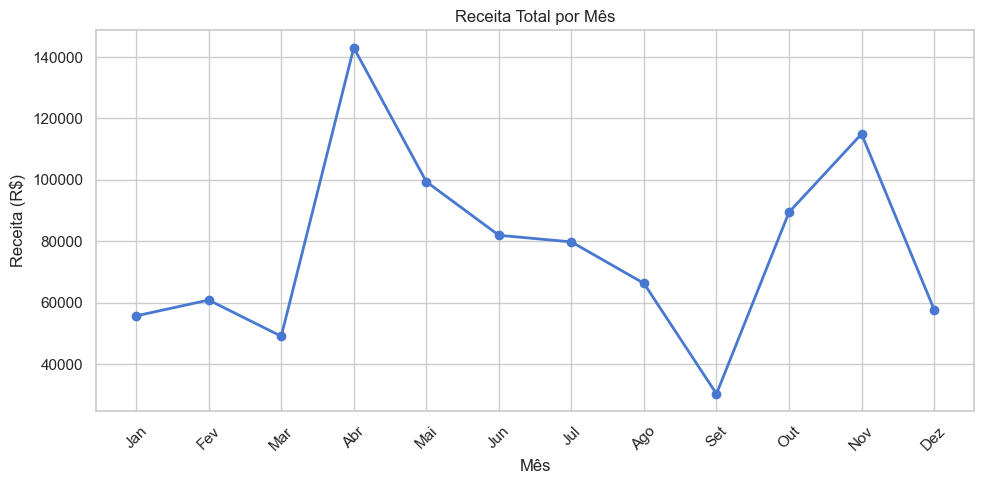

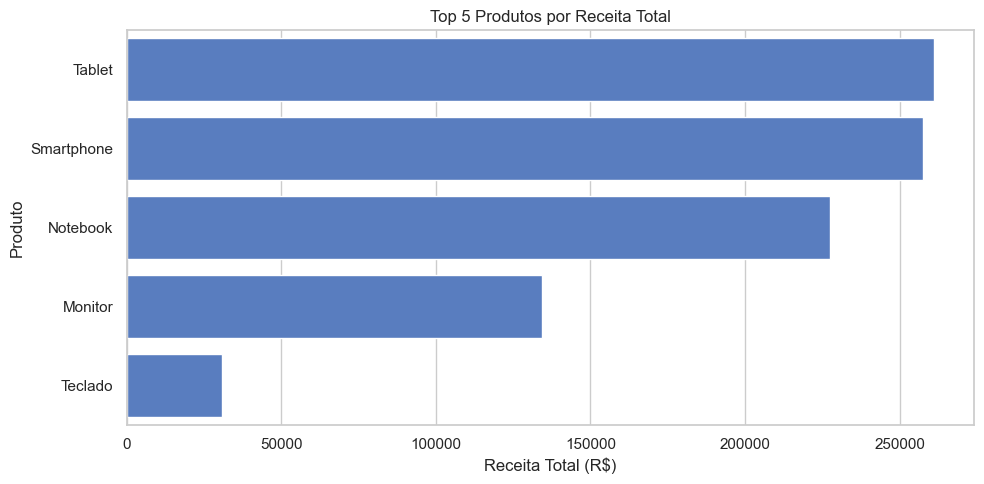

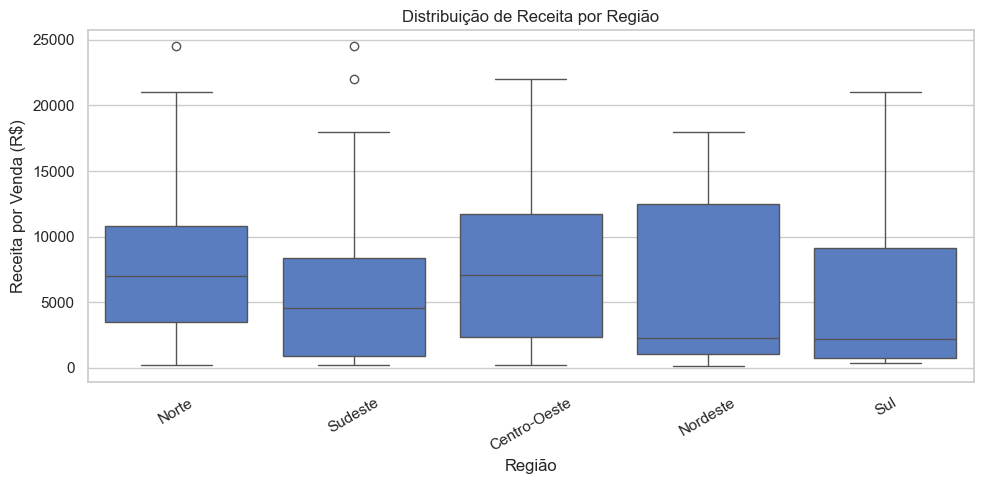

In [20]:
def gerar_visualizacoes(df, metricas, output_dir=os.path.join(BASE_DIR, "outputs", "graficos")):
    """Gera os gráficos de linha (receita/mês), barras (top 5
    produtos) e boxplot (receita por região)."""
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")
    meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
             "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

    # 1) Linha — tendência ao longo dos meses
    pm = metricas["por_mes"]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês"); ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses, rotation=45)
    fig.tight_layout(); fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show(); plt.close()

    # 2) Barras horizontais — ranking de produtos
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)"); ax.set_ylabel("Produto")
    fig.tight_layout(); fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show(); plt.close()

    # 3) Boxplot — dispersão e outliers por região
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região"); ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout(); fig.savefig(f"{output_dir}/dist_regiao.png", dpi=120)
    plt.show(); plt.close()


gerar_visualizacoes(df, metricas)

In [21]:
def aplicar_transformacao(df, coluna, funcao):
    """Função de ordem superior: aplica uma função lambda a uma coluna, 
    criando '<coluna>_transformado' sem altera a coluna original."""
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df


# Uso 1: classificar o ticket com lambda (2º uso de lambda no projeto)
df_demo = aplicar_transformacao(
    df, "receita_total", lambda x: "Alto" if x > 5000 else "Normal")
print("=== classificação por ticket ===")
print(df_demo[["receita_total", "receita_total_transformado"]].head())

# Uso 2: mostra que o mesmo callback aceita qualquer transformação
df_demo2 = aplicar_transformacao(
    df, "receita_total", lambda x: round(x / 1000, 2))
print("\n=== receita em milhares ===")
print(df_demo2[["receita_total", "receita_total_transformado"]].head())

=== classificação por ticket ===
   receita_total receita_total_transformado
0          240.0                     Normal
3          840.0                     Normal
4        10800.0                       Alto
6        14000.0                       Alto
7        13200.0                       Alto

=== receita em milhares ===
   receita_total  receita_total_transformado
0          240.0                        0.24
3          840.0                        0.84
4        10800.0                       10.80
6        14000.0                       14.00
7        13200.0                       13.20


In [22]:
def exportar_resultados(metricas, clientes, stats):
    """Exporta métricas e segmentação em CSV, e estatísticas em JSON"""
    pasta = os.path.join(BASE_DIR, "outputs", "relatorios")
    os.makedirs(pasta, exist_ok=True)

    metricas["por_mes"].to_csv(os.path.join(pasta, "metricas_por_mes.csv"),
                               index=False, encoding="utf-8-sig")
    clientes.to_csv(os.path.join(pasta, "segmentacao_clientes.csv"),
                    index=False, encoding="utf-8-sig")

    # JSON
    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = os.path.join(pasta, "estatisticas_gerais.json")
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"JSON exportado: {caminho_json}")
    
    # Leitura de volta para confirmar
    with open(caminho_json, encoding="utf-8") as f:
        lido = json.load(f)
    print("JSON relido:\n", json.dumps(lido, indent=2, ensure_ascii=False))


exportar_resultados(metricas, clientes, stats)

JSON exportado: ..\outputs\relatorios\estatisticas_gerais.json
JSON relido:
 {
  "media": 6928.73,
  "mediana": 5100.0,
  "desvio_padrao": 6449.66,
  "total": 928450.0,
  "p25": 1200.0,
  "p75": 10800.0,
  "acima_da_media": 60.0
}


In [23]:
# Decisão: usamos df_v2 (outliers tratados) como base final.
os.makedirs(os.path.join(BASE_DIR, "data", "final"), exist_ok=True)
df.to_csv(os.path.join(BASE_DIR, "data", "final", "vendas_final.csv"), index=False)
print("Dataset final salvo em: data/final/vendas_final.csv")

Dataset final salvo em: data/final/vendas_final.csv
